In [2]:
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient
login(UserSecretsClient().get_secret("token_medgemma"))

In [3]:
import json, re
import torch
import pandas as pd
from pathlib import Path
from PIL import Image
from transformers import AutoProcessor, AutoModelForMultimodalLM

# Modele charge UNE seule fois (4B parametres, GPU Kaggle requis)
MODEL_ID = "google/medgemma-4b-it"
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForMultimodalLM.from_pretrained(MODEL_ID, device_map="auto")
# Si cette classe erreur selon ta version de transformers, remplace par AutoModelForImageTextToText

processor_config.json:   0%|          | 0.00/70.0 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

The image processor of type `Gemma3ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

In [4]:
PROMPT_BASELINE = """You are an educational radiology assistant for engineering students.
You are not a clinician and you must not provide a definitive diagnosis.
Analyze the provided frontal chest X-ray: normal vs suspected lung opacity/pneumonia-related abnormality vs uncertain.
Return only valid JSON with this schema:
{"image_quality":"good|limited|poor","predicted_class":"normal|suspected_opacity|uncertain","confidence":0.0,"visual_evidence":["obs"],"justification":"2-4 cautious sentences","limitations":["lim"],"warning":"Educational prototype only. Not for diagnosis."}
Rules:
- Do not invent patient history.
- Do not mention findings that are not visible.
- Use "uncertain" when image quality is poor or evidence is weak.
- fill the confidence field with a score from 0.0 to 1.0 based on the certainty of your answer (quality of the image, signs apparent or not, etc.)
- Keep the response concise."""

PROMPT_IMPROVED = """You are an educational radiology assistant for engineering students.
You are not a clinician and are not expected to give a medical assistance, only an educationnal insight.

Analyze this frontal chest X-ray and classify it into one of three categories:
- "normal": lungs appear clear, no obvious opacity
- "suspected_opacity": opacification, consolidation or increased density visible
- "uncertain": image quality prevents reliable assessment

Step 1 — Describe what you observe (opacities, consolidations, lung volumes, symmetry).
Step 2 — Choose the most likely class based on your observations.
Step 3 — Rate your confidence honestly: if the visual signs are clear, confidence can be high (0.75-0.95). Only use "uncertain" if the image is genuinely unreadable or findings are truly ambiguous.

Important:
- A normal-looking chest should be classified as "normal", not "uncertain".
- Visible opacification should be classified as "suspected_opacity", not "uncertain".
- Reserve "uncertain" for cases where image quality prevents any reliable assessment.
- confidence < 0.50 forces predicted_class to "uncertain".
- Never invent patient history. No diagnosis language.

Return ONLY valid JSON:
{
  "image_quality": "good | limited | poor",
  "predicted_class": "normal | suspected_opacity | uncertain",
  "confidence": 0.0,
  "visual_evidence": ["observation 1", "observation 2"],
  "justification": "2-4 sentences describing findings and reasoning",
  "limitations": ["limitation 1"],
  "warning": "Educational prototype only. Not for diagnosis."
}"""

In [5]:
# =========================================================
# GARDE-FOUS (repris de guardrails.py, cahier des charges section "Objectif")
# =========================================================
from __future__ import annotations
import numpy as np

# Configuration issue du cahier des charges
ALLOWED_CLASSES = {"normal", "suspected_opacity", "uncertain"}
# NB : "warning" n'est PAS exige du VLM lui-meme. Ce champ est systematiquement
# injecte/ecrase par apply_safety_guardrails (WARNING_TEXT), qu'il soit valide ou non.
# L'exiger ici invaliderait le schema de TOUTE sortie tronquee par max_new_tokens
# avant d'atteindre ce dernier champ -> tout serait force en "uncertain" a tort
# (bug observe en pratique : guardrail_rate=1.0 systematique).
REQUIRED_KEYS = {"image_quality", "predicted_class", "confidence", "visual_evidence", "justification", "limitations"}
WARNING_TEXT = "Prototype pedagogique. Non destine au diagnostic. Validation par un professionnel qualifie requise."


def check_image_quality(image_path):
    """
    Verifie la qualite technique de la radiographie (CXR) AVANT soumission au VLM.
    Filtre de securite amont pour eviter le traitement d'images inexploitables.
    """
    img = Image.open(image_path).convert("L")  # niveaux de gris
    arr = np.array(img, dtype=np.float32)

    issues = []

    mean_brightness = arr.mean()
    if mean_brightness < 30:
        issues.append("(trop sombre)")
    elif mean_brightness > 220:
        issues.append("(trop claire)")

    std = arr.std()
    if std < 20:
        issues.append("contraste trop faible")

    w, h = img.size
    if w < 224 or h < 224:
        issues.append(f"resolution insuffisante ({w}x{h})")

    ratio = w / h
    if ratio < 0.7 or ratio > 1.4:
        issues.append(f"ratio d'aspect inhabituel ({ratio:.2f})")

    pct_black = (arr < 5).mean()
    pct_white = (arr > 250).mean()
    if pct_black > 0.5:
        issues.append(f"trop de pixels noirs ({pct_black:.0%})")
    if pct_white > 0.3:
        issues.append(f"trop de pixels satures ({pct_white:.0%})")

    if len(issues) >= 2:
        quality = "poor"
    elif issues:
        quality = "limited"
    else:
        quality = "good"

    return {"quality": quality, "issues": issues}


def validate_prediction(pred):
    """Valide la conformite structurelle et clinique du JSON produit par le VLM."""
    errors = []

    missing = REQUIRED_KEYS - set(pred)
    if missing:
        errors.append(f"missing keys: {sorted(missing)}")

    if pred.get("predicted_class") not in ALLOWED_CLASSES:
        errors.append("invalid predicted_class")

    try:
        conf = float(pred.get("confidence", -1))
        if not (0 <= conf <= 1):
            errors.append("confidence outside [0,1]")
    except (TypeError, ValueError):
        errors.append("confidence is not numeric")

    # "warning" n'est pas verifie ici : c'est un champ reglementaire controle par
    # apply_safety_guardrails, pas une exigence de sortie du VLM (voir REQUIRED_KEYS).

    return not errors, errors


def apply_safety_guardrails(pred):
    """
    Applique le filet de securite (post-processing). Force la prudence si le
    schema est invalide ou si la qualite de l'image est degradee.
    """
    valid, errors = validate_prediction(pred)

    if not valid:
        pred["predicted_class"] = "uncertain"
        try:
            current_conf = float(pred.get("confidence", 0.0))
            pred["confidence"] = min(current_conf, 0.5)
        except (TypeError, ValueError):
            pred["confidence"] = 0.0

        current_limits = pred.get("limitations")
        if isinstance(current_limits, list):
            current_limits.append("guardrail triggered: invalid output schema")
        elif isinstance(current_limits, str):
            pred["limitations"] = [current_limits, "guardrail triggered: invalid output schema"]
        else:
            pred["limitations"] = ["guardrail triggered: invalid output schema"]

    try:
        conf_value = float(pred.get("confidence", 0.0))
    except (TypeError, ValueError):
        conf_value = 0.0

    if pred.get("image_quality") in {"limited", "poor"} and conf_value < 0.6:
        pred["predicted_class"] = "uncertain"

    pred["warning"] = WARNING_TEXT
    pred["guardrail_errors"] = errors

    return pred


CXR_LEXICON = {"poumon", "poumons", "thorax", "thoracique", "plevre", "coeur", "diaphragme", "mediastin", "lung", "chest", "opacity", "infiltrat"}

def check_hallucination_lexicon(pred):
    """Verifie si le texte genere contient au moins un mot-cle du domaine thoracique."""
    text_to_check = f"{pred.get('visual_evidence', '')} {pred.get('justification', '')}".lower()

    if pred.get("predicted_class") in {"normal", "suspected_opacity"}:
        if not any(word in text_to_check for word in CXR_LEXICON):
            return False, "Le modele semble hors-sujet ou l'image n'est pas une radiographie thoracique."

    return True, None


CRITICAL_KEYWORDS = {"grave", "foudroyant", "masse", "pneumothorax", "epanchement", "detresse"}

def check_semantic_coherence(pred):
    """Empeche le modele de classer en 'normal' si le texte contient des indices de pathologie lourde."""
    justification = str(pred.get("justification", "")).lower()
    predicted_class = pred.get("predicted_class")

    if predicted_class == "normal" and any(word in justification for word in CRITICAL_KEYWORDS):
        return False, "Incoherence semantique detectee (mots critiques trouves pour une classe 'normal')."

    return True, None


def apply_uncertainty_threshold(pred, lower_bound=0.4, upper_bound=0.65):
    """Si la confiance est dans la zone grise, force la classe 'uncertain'."""
    try:
        conf = float(pred.get("confidence", 0.0))
    except (TypeError, ValueError):
        conf = 0.0

    if lower_bound <= conf <= upper_bound:
        if pred.get("predicted_class") != "uncertain":
            pred["predicted_class"] = "uncertain"
            pred.setdefault("limitations", []).append(f"Classe modifiee en 'uncertain' : confiance dans la zone grise ({conf:.2f}).")

    return pred


def finalize_prediction(pred):
    """
    Chaine complete de garde-fous AVAL, appliquee a toute prediction (VLM ou repli
    pre-VLM) avant qu'elle ne soit retournee/loggee :
      1) conformite structurelle + reglementaire      -> apply_safety_guardrails
      2) coherence lexicale (hors-sujet / hallucination) -> check_hallucination_lexicon
      3) coherence semantique (texte vs classe)        -> check_semantic_coherence
      4) seuil d'incertitude (zone grise de confiance)  -> apply_uncertainty_threshold
    Chaque etape peut degrader la prediction vers "uncertain" mais jamais l'inverse.
    Retourne pred enrichi de pred["guardrails_triggered"] (liste des garde-fous declenches),
    utile pour le CSV de metriques et le registre d'erreurs demandes par le cahier des charges.
    """
    triggered = []

    pred = apply_safety_guardrails(pred)
    if pred.get("guardrail_errors"):
        triggered.append("schema_or_regulatory")

    ok_lexicon, msg_lexicon = check_hallucination_lexicon(pred)
    if not ok_lexicon:
        pred["predicted_class"] = "uncertain"
        pred.setdefault("limitations", []).append(msg_lexicon)
        triggered.append("hallucination_lexicon")

    ok_coherence, msg_coherence = check_semantic_coherence(pred)
    if not ok_coherence:
        pred["predicted_class"] = "uncertain"
        pred.setdefault("limitations", []).append(msg_coherence)
        triggered.append("semantic_coherence")

    before_class = pred.get("predicted_class")
    pred = apply_uncertainty_threshold(pred)
    if pred.get("predicted_class") != before_class:
        triggered.append("uncertainty_threshold")

    # Le warning reglementaire doit toujours etre present, quelle que soit la voie empruntee
    pred["warning"] = WARNING_TEXT
    pred["guardrails_triggered"] = triggered

    return pred


In [7]:
import re
import json


def parse_prediction(text):
    """
    Parse la sortie brute du VLM en dictionnaire structure conforme au schema
    REQUIRED_KEYS attendu par les garde-fous (image_quality, predicted_class,
    confidence, visual_evidence, justification, limitations, warning).

    Strategie :
      1) on tente un parsing JSON strict sur le premier bloc {...} trouve ;
      2) si le JSON est absent/corrompu (sortie degradee du VLM), on retombe
         sur une extraction champ par champ, sans jamais planter.
    """
    output = {}

    match_json = re.search(r"\{.*\}", text, re.DOTALL)
    if match_json:
        try:
            parsed = json.loads(match_json.group(0))
            if isinstance(parsed, dict):
                output.update(parsed)
        except json.JSONDecodeError:
            pass

    # --- Repli champ par champ si le JSON est absent ou incomplet ---
    # (frequent : max_new_tokens peut couper le JSON avant sa fermeture "}")
    def _extract_string_field(key):
        # capture le texte apres "key": " ... jusqu'au prochain champ, a la
        # fermeture du guillemet, ou a la fin (troncature) si rien de tout ca n'apparait
        pattern = rf'"{key}"\s*:\s*"(.*?)(?:"\s*,\s*"[a-zA-Z_]+"\s*:|"\s*\}}|$)'
        m = re.search(pattern, text, re.DOTALL)
        return m.group(1).strip() if m else ""

    def _extract_list_field(key):
        pattern = rf'"{key}"\s*:\s*\[(.*?)(?:\]|"[a-zA-Z_]+"\s*:|$)'
        m = re.search(pattern, text, re.DOTALL)
        if not m:
            return []
        return re.findall(r'"([^"]*)"', m.group(1))

    if "predicted_class" not in output:
        if re.search(r'predicted_class"?\s*:\s*"?normal', text):
            output["predicted_class"] = "normal"
        elif re.search(r'predicted_class"?\s*:\s*"?suspe?cted_opacity', text):
            output["predicted_class"] = "suspected_opacity"
        else:
            output["predicted_class"] = "uncertain"
            print("default case #1 : predicted_class absent/illisible -> uncertain")

    # Normalisation des synonymes courants avant validation stricte : le modele
    # devie parfois du vocabulaire exact demande (ex: "unsure" au lieu de
    # "uncertain") sans que ce soit une vraie derive de schema a signaler.
    CLASS_ALIASES = {
        "unsure": "uncertain", "not sure": "uncertain", "ambiguous": "uncertain",
        "indeterminate": "uncertain", "unclear": "uncertain",
        "abnormal": "suspected_opacity", "opacity": "suspected_opacity",
        "suspicious": "suspected_opacity",
        "clear": "normal", "no finding": "normal", "no abnormality": "normal",
    }
    if output.get("predicted_class") in CLASS_ALIASES:
        output["predicted_class"] = CLASS_ALIASES[output["predicted_class"]]

    if "confidence" not in output:
        match = re.search(r'"confidence":\s*([\d.]+)', text)
        if match:
            try:
                output["confidence"] = float(match.group(1))
            except ValueError:
                output["confidence"] = 0.0
        else:
            print("default case #2 : confidence absente -> 0.0")
            output["confidence"] = 0.0

    # Champs textuels exploites par les garde-fous (lexique, coherence semantique) :
    # meme si le JSON global est corrompu/tronque, on tente de recuperer le texte
    # deja genere plutot que de tomber sur des valeurs vides par defaut.
    output.setdefault("image_quality", "limited")
    if not output.get("visual_evidence"):
        output["visual_evidence"] = _extract_list_field("visual_evidence")
    if not output.get("justification"):
        output["justification"] = _extract_string_field("justification")
    if not output.get("limitations"):
        output["limitations"] = _extract_list_field("limitations")
    output.setdefault("warning", "")

    output["raw"] = text
    return output


def predict_chest_xray(image_path, prompt):
    """
    Pipeline complet : garde-fou amont (qualite technique) -> inference VLM
    (si l'image est exploitable) -> garde-fous aval (finalize_prediction).
    """
    # --- Garde-fou AMONT : controle technique avant tout appel au VLM ---
    quality_check = check_image_quality(image_path)

    if quality_check["quality"] == "poor":
        # Image techniquement inexploitable : on evite l'appel au modele
        # (cout de calcul + risque d'hallucination sur une image illisible)
        # et on retourne directement un repli prudent, qui passe quand
        # meme par finalize_prediction pour rester homogene avec le reste du pipeline.
        pred = {
            "image_quality": "poor",
            "predicted_class": "uncertain",
            "confidence": 0.0,
            "visual_evidence": [],
            "justification": "Image rejetee en amont : qualite technique insuffisante pour analyse.",
            "limitations": [f"guardrail (pre-VLM): {issue}" for issue in quality_check["issues"]],
            "warning": "",
            "raw": None,
            "technical_quality_issues": quality_check["issues"],
            "inference_skipped": True,
        }
        return finalize_prediction(pred)

    image = Image.open(image_path).convert("RGB")
    messages = [{"role": "user", "content": [
        {"type": "image", "image": image},
        {"type": "text", "text": prompt},
    ]}]
    inputs = processor.apply_chat_template(
        messages, add_generation_prompt=True, tokenize=True,
        return_dict=True, return_tensors="pt",
    ).to(model.device, dtype=model.dtype)
    input_len = inputs["input_ids"].shape[-1]
    with torch.inference_mode():
        # max_new_tokens releve de 150 -> 400 : a 150, le JSON etait quasi
        # systematiquement tronque avant sa fermeture, ce qui degradait
        # artificiellement toutes les predictions vers "uncertain".
        outputs = model.generate(**inputs, max_new_tokens=400, do_sample=False, repetition_penalty=1.3)
    text = processor.decode(outputs[0][input_len:], skip_special_tokens=True).strip()

    del inputs, outputs
    torch.cuda.empty_cache()

    pred = parse_prediction(text)
    pred["technical_quality_issues"] = quality_check["issues"]
    pred["inference_skipped"] = False

    # --- Fusion prudente de la qualite : on retient la PIRE des deux estimations ---
    # (auto-evaluation du VLM vs mesure technique objective sur les pixels)
    quality_rank = {"good": 0, "limited": 1, "poor": 2}
    model_quality = pred.get("image_quality", "limited")
    if model_quality not in quality_rank:
        model_quality = "limited"
    pred["image_quality"] = max(model_quality, quality_check["quality"], key=lambda q: quality_rank[q])

    # --- Garde-fous AVAL : schema, hallucination, coherence semantique, seuil d'incertitude ---
    return finalize_prediction(pred)


In [8]:
# A ADAPTER : dossier Kaggle qui contient train/ et train.csv
# (regarde le chemin exact dans le panneau de droite "Input" sur Kaggle)
from pathlib import Path
DATA_ROOT = next(p.parent for p in Path("/kaggle/input").rglob("train.csv"))
CSV_PATH  = DATA_ROOT / "train.csv"
print("DATA_ROOT =", DATA_ROOT)
OPACITY_COLS = ["Lung Opacity", "Consolidation", "Pneumonia", "Edema", "Atelectasis"]


def ground_truth(row):
    if row["No Finding"] == 1.0:
        return "normal"
    if any(row.get(c) == 1.0 for c in OPACITY_COLS):
        return "suspected_opacity"
    return "uncertain"   


def image_path_from_row(row):
    rel = row["Path"].split("/", 1)[1]   # retire le prefixe "CheXpert-v1.0-small/"
    return DATA_ROOT / rel


def build_sample(n, seed=42):
    df = pd.read_csv(CSV_PATH)
    df = df[df["Frontal/Lateral"] == "Frontal"].copy()
    df["gt"] = df.apply(ground_truth, axis=1)
    df = df[df["gt"].notna()]
    return df.sample(n=n, random_state=seed)   # meme echantillon avec le meme seed


def evaluate(prompt, sample):
    correct = committed = uncertain = 0
    guardrail_hits = 0   # nb d'images ou au moins un garde-fou aval s'est declenche

    for _, row in sample.iterrows():

        output = predict_chest_xray(image_path_from_row(row), prompt)
        pred = output["predicted_class"]
        print(output)

        if output.get("guardrails_triggered"):
            guardrail_hits += 1

        if pred == "uncertain":
            uncertain += 1

            is_clearly_healthy = row["No Finding"] == 1.0
            is_clearly_sick = any(row[c] == 1.0 for c in OPACITY_COLS)

            if not (is_clearly_healthy or is_clearly_sick):  # ambiguite justifiee
                correct += 1


        elif pred == row["gt"]:
            correct += 1
            committed += 1


    return {
        # correct/len(sample) et non correct/committed : "correct" inclut aussi
        # les "uncertain" justifies (cas ambigus), pas seulement les commits.
        # Le "if committed else 0.0" a ete retire : il forcait l'accuracy a 0
        # des qu'aucun commit n'etait correct, meme si des uncertain l'etaient.
        "accuracy": round(correct / len(sample), 4),
        "coverage": round(committed / len(sample), 4),      # % de cas ou le modele s engage
        "uncertain_rate": round(uncertain / len(sample), 4),
        "guardrail_rate": round(guardrail_hits / len(sample), 4),  # % de cas corriges par un garde-fou
        "n": len(sample),
    }


DATA_ROOT = /kaggle/input/datasets/ashery/chexpert


In [10]:
sample = build_sample(4, seed=51)
res_baseline = evaluate(PROMPT_BASELINE, sample)
res_baseline

{'image_quality': 'good', 'predicted_class': 'uncertain', 'confidence': 0.65, 'visual_evidence': ['right lower lobe opacities suggesting pneumonia.', 'possible pleural effusion in right hemithorax'], 'justification': "The radiograph shows increased density within the right lower lobe which could be indicative of consolidation due to infection like Pneumonia . There's also some blunting seen at what appears to be costophrenic angle suggestive possible small amount fluid collection but it can have other causes as well such as atelectasis.. The overall appearance warrants further investigation by clinical correlation if there were any symptoms present.", 'limitations': ["Classe modifiee en 'uncertain' : confiance dans la zone grise (0.65)."], 'warning': 'Prototype pedagogique. Non destine au diagnostic. Validation par un professionnel qualifie requise.', 'raw': '```json\n{\n  "image_quality": "good",\n  "predicted_class": "suspected_opacity",\n  "confidence": 0.65,\n  "visual_evidence": [

{'accuracy': 0.3333,
 'coverage': 0.0,
 'uncertain_rate': 0.6667,
 'guardrail_rate': 0.3333,
 'n': 3}

In [1]:
# Comparaison baseline vs improved sur les MEMES images
sample = build_sample(6, seed=22)
res_baseline = evaluate(PROMPT_BASELINE, sample)
res_improved = evaluate(PROMPT_IMPROVED, sample)

import pandas as pd
pd.DataFrame([
    {"prompt": "baseline", **res_baseline},
    {"prompt": "improved", **res_improved},
])



NameError: name 'build_sample' is not defined

# Test majeur accuracy : 

In [9]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Les 3 classes possibles en SORTIE du modèle. "uncertain" n'existe jamais comme vérité terrain
# (ground_truth() ne renvoie que "normal" / "suspected_opacity", les cas ambigus sont exclus),
# mais on la garde dans les labels pour voir A QUEL POINT le modèle "botte en touche" et sur quelles vraies classes.
LABELS = ["normal", "suspected_opacity", "uncertain"]

In [10]:
def evaluate_full(prompt, sample, save_path="/kaggle/working/eval_results.csv", verbose=True):
    """
    Evalue le modele sur `sample` (DataFrame avec colonnes utilisees par image_path_from_row et 'gt').
    Sauvegarde un checkpoint CSV apres CHAQUE image (utile si la session coupe en cours de route).
    Le CSV inclut la qualite d'image, les garde-fous declenches et les limitations,
    ce qui sert directement de base au registre d'erreurs (20-30 cas commentes) et
    au dashboard de metriques demandes par le cahier des charges.
    Retourne accuracy, matrice de confusion, rapport precision/recall/F1 et le detail par image.
    """
    records = []
    t0 = time.time()

    for i, (_, row) in enumerate(sample.iterrows()):
        img_path = image_path_from_row(row)
        gt = row["gt"]

        try:
            output = predict_chest_xray(img_path, prompt)
        except Exception as e:
            output = {
                "predicted_class": "uncertain", "confidence": 0.0, "raw": f"ERROR: {e}",
                "image_quality": "poor", "guardrails_triggered": ["exception"],
                "limitations": [f"exception: {e}"], "inference_skipped": True,
            }

        pred = output.get("predicted_class", "uncertain")
        records.append({
            "path": str(img_path),
            "gt": gt,
            "pred": pred,
            "confidence": output.get("confidence", 0.0),
            "image_quality": output.get("image_quality", ""),
            "inference_skipped": output.get("inference_skipped", False),
            "guardrails_triggered": ";".join(output.get("guardrails_triggered", [])),
            "limitations": " | ".join(str(l) for l in output.get("limitations", [])),
            "raw": output.get("raw", ""),
        })

        if verbose:
            elapsed = time.time() - t0
            flag = " [guardrail]" if output.get("guardrails_triggered") else ""
            print(f"[{i+1}/{len(sample)}] gt={gt:<18} pred={pred:<18} "
                  f"conf={output.get('confidence', 0.0):.2f}  ({elapsed:.0f}s ecoulees){flag}")

        if save_path:
            pd.DataFrame(records).to_csv(save_path, index=False)  # checkpoint incremental

    results_df = pd.DataFrame(records)
    y_true = results_df["gt"]
    y_pred = results_df["pred"]

    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    report = classification_report(y_true, y_pred, labels=LABELS, zero_division=0, output_dict=True)
    report_df = pd.DataFrame(report).transpose().round(4)

    print(f"\n=== Accuracy globale : {acc:.4f}  ({len(results_df)} images) ===\n")
    print(report_df)

    guardrail_rate = (results_df["guardrails_triggered"] != "").mean()
    print(f"=== Garde-fous declenches sur {guardrail_rate:.2%} des images ===\n")

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=LABELS, yticklabels=LABELS, ax=ax)
    ax.set_xlabel("Prediction du modele")
    ax.set_ylabel("Verite terrain (CheXpert)")
    ax.set_title(f"Matrice de confusion — accuracy={acc:.2%}")
    plt.tight_layout()
    plt.show()

    return {
        "accuracy": acc,
        "confusion_matrix": cm,
        "report": report_df,
        "results_df": results_df,
    }


[1/100] gt=suspected_opacity  pred=suspected_opacity  conf=0.80  (19s ecoulees)
[2/100] gt=suspected_opacity  pred=suspected_opacity  conf=0.80  (37s ecoulees)
[3/100] gt=suspected_opacity  pred=normal             conf=0.80  (55s ecoulees)
[4/100] gt=normal             pred=normal             conf=0.85  (73s ecoulees)
[5/100] gt=suspected_opacity  pred=normal             conf=0.80  (92s ecoulees)
[6/100] gt=suspected_opacity  pred=suspected_opacity  conf=0.60  (110s ecoulees)
[7/100] gt=uncertain          pred=normal             conf=0.85  (129s ecoulees)
[8/100] gt=suspected_opacity  pred=suspected_opacity  conf=0.60  (147s ecoulees)
[9/100] gt=suspected_opacity  pred=suspected_opacity  conf=0.60  (166s ecoulees)
[10/100] gt=normal             pred=normal             conf=0.85  (184s ecoulees)
[11/100] gt=suspected_opacity  pred=suspected_opacity  conf=0.60  (203s ecoulees)
[12/100] gt=suspected_opacity  pred=normal             conf=0.60  (222s ecoulees)
[13/100] gt=suspected_opacity 

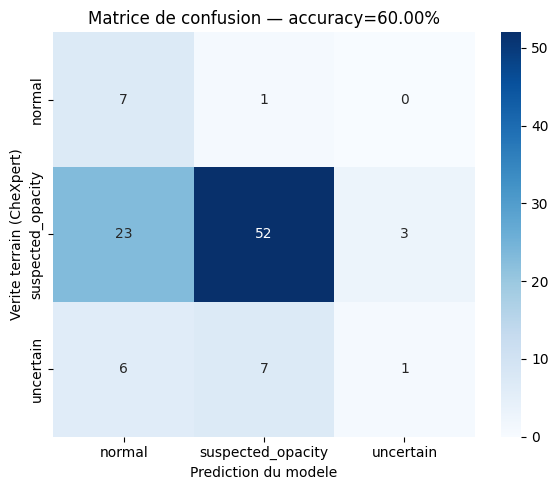

In [9]:
sample_100 = build_sample(100, seed=123)
results = evaluate_full(PROMPT_IMPROVED, sample_100, save_path="/kaggle/working/eval_results_improved.csv")


In [11]:
sample_100 = build_sample(100, seed=123)
results = evaluate_full(PROMPT_BASELINE, sample_100, save_path="/kaggle/working/eval_results_improved.csv")


KeyboardInterrupt: 